In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import plotly.graph_objects as go

In [ ]:
class SingleBetaCell:
    def __init__(
        self,
        gs1=5,
        gs2=32,
        taus1=1000,
        taus2=120000,
        tnbar=9.09,
        vs1=-40,
        vs2=-42,
        ss1=0.5,
        ss2=0.4,
        s1knot=1,
        s2knot=1,
        gl=25,
        vl=-40,
        gk=1300,
        vk=-80,
        gca=280,
        vca=100,
        lambda_=1.1,
        cm=4524,
        vm=-22,
        sm=7.5,
        vn=-9,
        sn=10,
    ):
        self.gs1 = gs1
        self.gs2 = gs2
        self.taus1 = taus1
        self.taus2 = taus2
        self.tnbar = tnbar
        self.vs1 = vs1
        self.vs2 = vs2
        self.ss1 = ss1
        self.ss2 = ss2
        self.s1knot = s1knot
        self.s2knot = s2knot
        self.gl = gl
        self.vl = vl
        self.gk = gk
        self.vk = vk
        self.gca = gca
        self.vca = vca
        self.lambda_ = lambda_
        self.cm = cm
        self.vm = vm
        self.sm = sm
        self.vn = vn
        self.sn = sn

    def dynamics(self, t, x, v_neighbors, g_total):
        v, n, s1, s2 = x

        minf = 1.0 / (1.0 + np.exp((self.vm - v) / self.sm))
        ninf = 1.0 / (1.0 + np.exp((self.vn - v) / self.sn))
        taun = self.tnbar / (1.0 + np.exp((v - self.vn) / self.sn))
        s1inf = 1.0 / (1.0 + np.exp((self.vs1 - v) / self.ss1))
        s2inf = 1.0 / (1.0 + np.exp((self.vs2 - v) / self.ss2))

        ica = self.gca * minf * (v - self.vca)
        ik = self.gk * n * (v - self.vk)
        il = self.gl * (v - self.vl)
        is1 = self.gs1 * s1 * (v - self.vk)
        is2 = self.gs2 * s2 * (v - self.vk)

        igj = g_total * (v_neighbors - v) if g_total > 0 else 0

        vdot = -(ica + ik + il + is1 + is2 - igj) / self.cm
        ndot = self.lambda_ * (ninf - n) / taun
        s1dot = (s1inf - s1) / self.taus1
        s2dot = (s2inf - s2) / self.taus2

        return np.array([vdot, ndot, s1dot, s2dot])

class BetaCellNetwork:
    def __init__(self, num_cells=2, mean_gj=0, std_gj=0, min_connections=1, max_connections=2):
        self.num_cells = num_cells
        self.mean_gj = mean_gj
        self.std_gj = std_gj
        self.min_connections = min_connections
        self.max_connections = max_connections

        self.cells = [
            SingleBetaCell(
                gs1=np.random.normal(5, 0.05), 
                gs2=np.random.normal(32, 0.2)
            ) for _ in range(num_cells)
        ]

        self.create_network()

    def create_network(self):
        self.adjacency_matrix = np.zeros((self.num_cells, self.num_cells))
        self.gj_matrix = np.zeros((self.num_cells, self.num_cells))
        self.graph = nx.Graph()
        self.graph.add_nodes_from(range(self.num_cells))

        for i in range(self.num_cells):
            num_connections = np.random.randint(self.min_connections, self.max_connections)
            possible_connections = [j for j in range(self.num_cells) if j != i and self.adjacency_matrix[i, j] == 0]
            connections = np.random.choice(possible_connections, size=min(num_connections, len(possible_connections)), replace=False)
            for j in connections:
                gj_value = max(0, np.random.normal(self.mean_gj, self.std_gj))
                self.adjacency_matrix[i, j] = self.adjacency_matrix[j, i] = 1
                self.gj_matrix[i, j] = self.gj_matrix[j, i] = gj_value
                self.graph.add_edge(i, j)
                # make the size of the edge proportional to gj_value
                self.graph.edges[i, j]['weight'] = gj_value

    def network_dynamics(self, t, X):
        dXdt = np.zeros_like(X)
        for i, cell in enumerate(self.cells):
            idx = 4 * i
            vi = X[idx]
            vi_neighbors = 0
            g_total = 0
            for j in range(self.num_cells):
                if i != j and self.adjacency_matrix[i, j]:
                    vj = X[4 * j]
                    gj = self.gj_matrix[i, j]
                    vi_neighbors += gj * vj
                    g_total += gj
            v_neighbors = vi_neighbors / g_total if g_total > 0 else vi
            dXdt[idx:idx + 4] = cell.dynamics(t, X[idx:idx + 4], v_neighbors, g_total)
        return dXdt

    def simulate(self, tmax=90000, max_step=5.0):
        X0 = np.array([-50, 0, 0, 0.6] * self.num_cells)
        tspan = (0, tmax)
        sol = solve_ivp(self.network_dynamics, tspan, X0, method="RK45", max_step=max_step)
        return sol

    def plot_results(self, sol):
        """
        Plot simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        """
        # Convert time from ms to seconds
        tsec = sol.t / 1000

        # Create a figure with multiple subplots
        fig = plt.figure(figsize=(15, 12))

        # Plot voltages
        ax1 = fig.add_subplot(3, 1, 1)
        for i in range(self.num_cells):
            v = sol.y[i * 4]
            ax1.plot(
                tsec, v, linewidth=1, alpha=0.7, label=f"Cell {i+1}" if i < 5 else ""
            )

        ax1.set_xlim(0, tsec[-1])
        ax1.set_ylim(-70, -10)
        ax1.set_ylabel("V (mV)")
        ax1.set_title(f"Membrane Potentials of {self.num_cells} Coupled Beta Cells")
        if self.num_cells <= 5:
            ax1.legend(loc="upper right")
        else:
            ax1.legend(loc="upper right", ncol=2)

        # Plot s1 variables
        ax2 = fig.add_subplot(3, 1, 2)
        for i in range(self.num_cells):
            s1 = sol.y[i * 4 + 2]
            ax2.plot(tsec, s1, linewidth=1, alpha=0.7)

        ax2.set_xlim(0, tsec[-1])
        ax2.set_ylim(0, 1)
        ax2.set_xlabel("t (s)")
        ax2.set_ylabel("s₁")
        ax2.set_title("Slow Variable s₁")

        # Plot s2 variables
        ax3 = fig.add_subplot(3, 1, 3)
        for i in range(self.num_cells):
            s2 = sol.y[i * 4 + 3]
            ax3.plot(tsec, s2, linewidth=1, alpha=0.7)

        ax3.set_xlim(0, tsec[-1])
        ax3.set_ylim(0, 1)
        ax3.set_xlabel("t (s)")
        ax3.set_ylabel("s₂")
        ax3.set_title("Slow Variable s₂")

        plt.tight_layout()
        plt.show()

    def plot_network(self):
        pos = nx.spring_layout(self.graph)
        nx.draw(self.graph, pos, with_labels=True, node_color='skyblue', node_size=1000, edge_color='gray')
        plt.title("Beta Cell Network")
        plt.show()

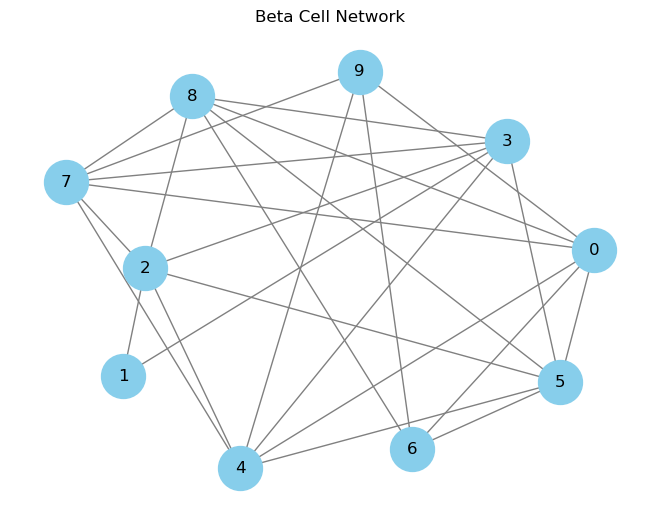

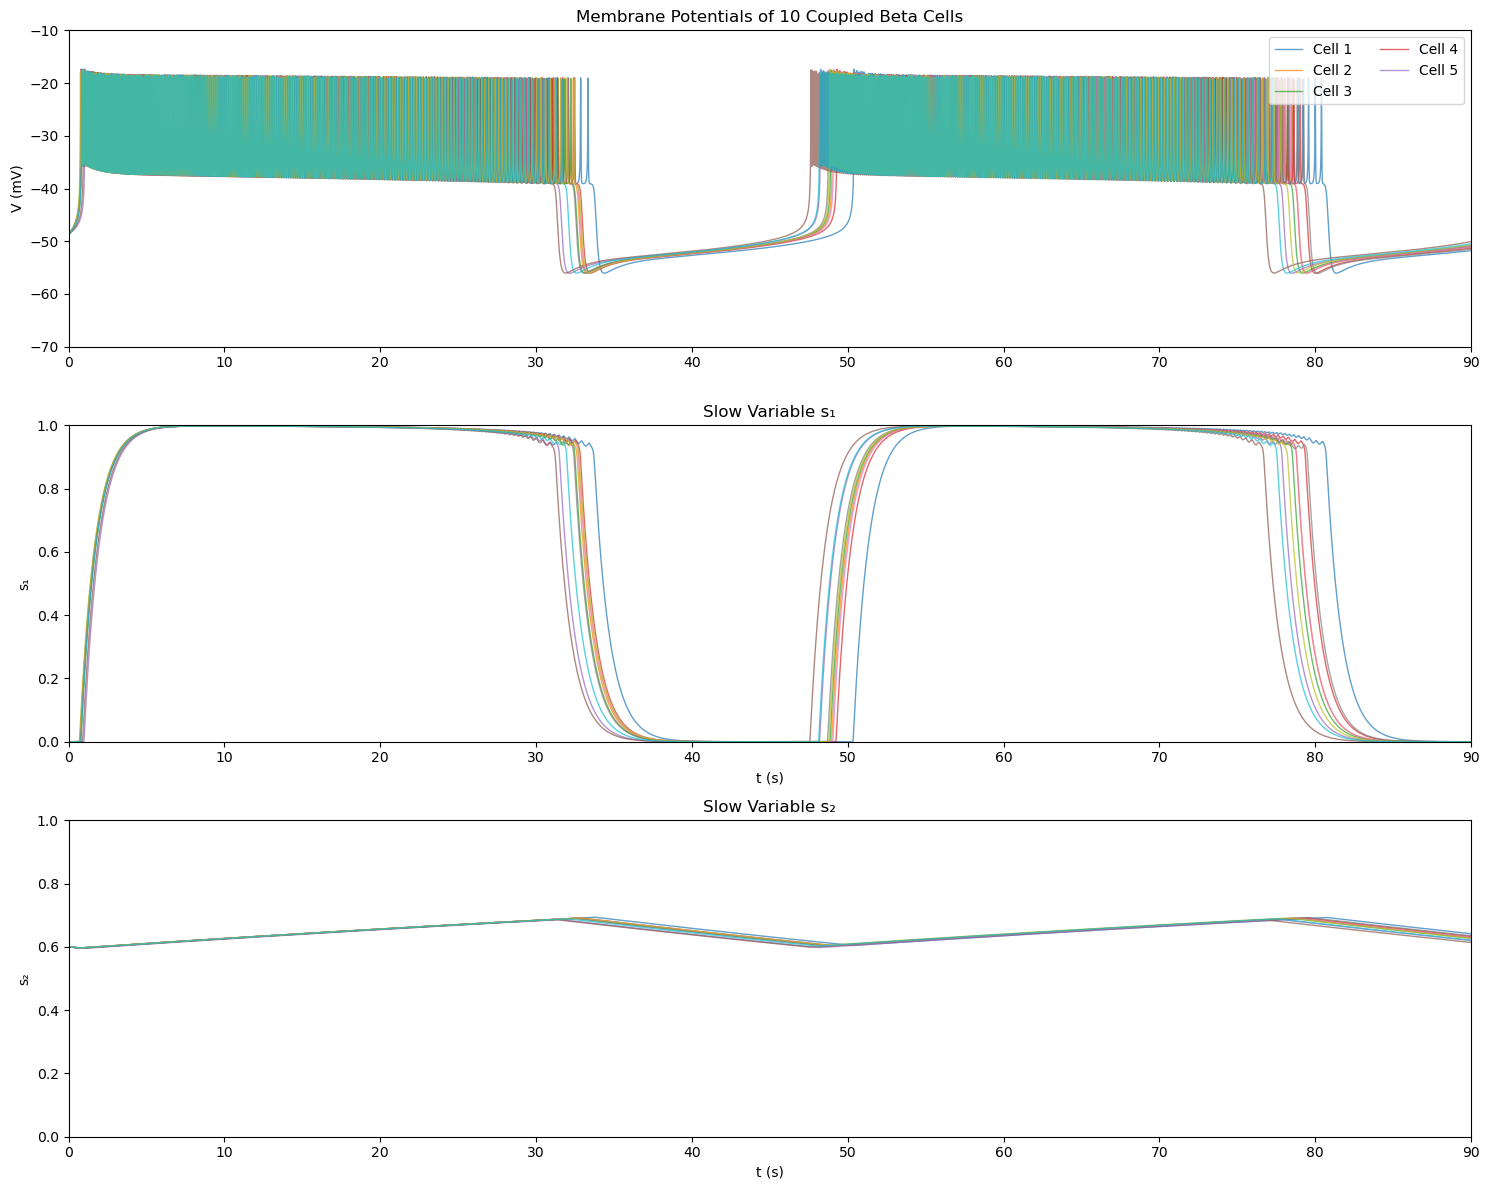

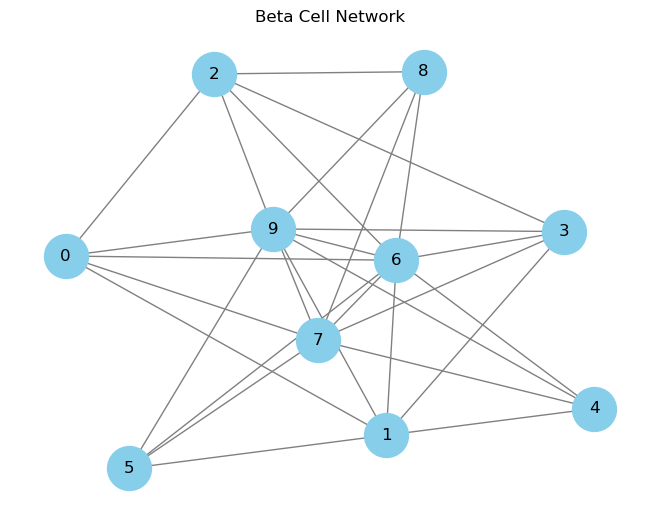

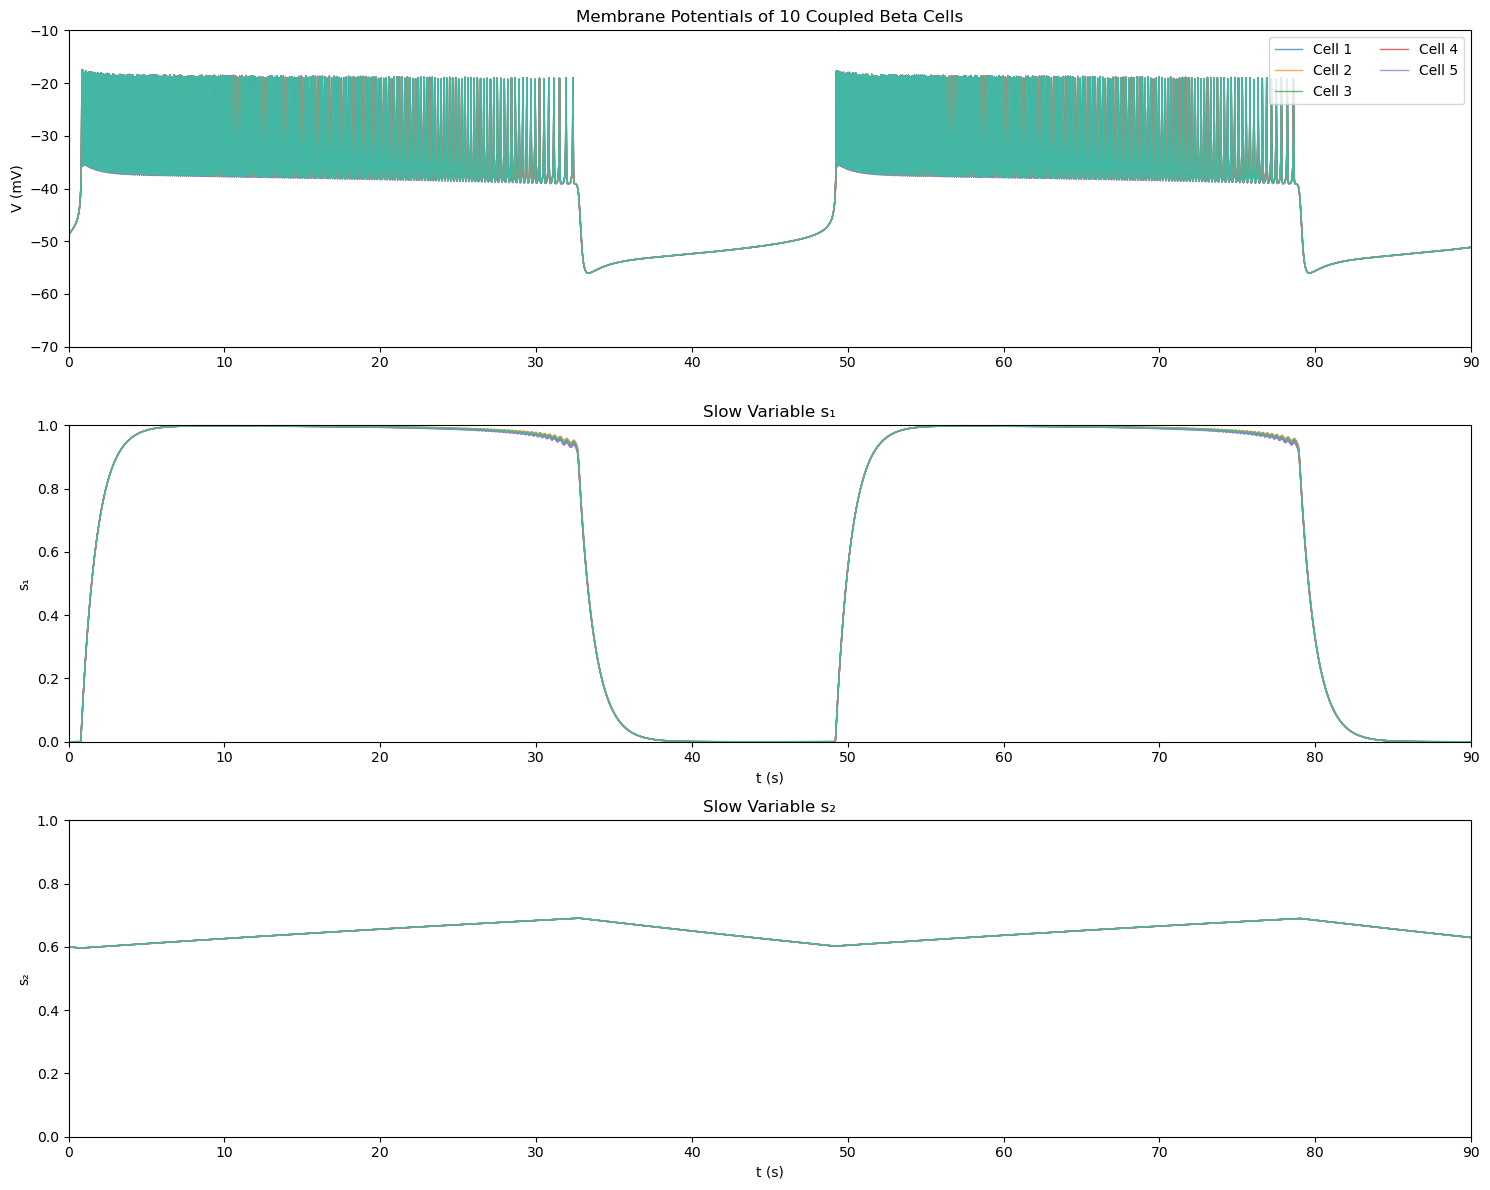

In [65]:
def main():
    network = BetaCellNetwork(
        num_cells=10, mean_gj=0, std_gj=0, min_connections=1, max_connections=5
    )
    network.plot_network()
    sol = network.simulate(tmax=90000)
    network.plot_results(sol)

    gj_connected = BetaCellNetwork(
        num_cells=10, mean_gj=40, std_gj=8, min_connections=1, max_connections=5
    )
    gj_connected.plot_network()
    sol_connected = gj_connected.simulate(tmax=90000)
    gj_connected.plot_results(sol_connected)

main()

In [4]:
class SingleDeltaCell:
    def __init__(self, **kwargs):
        """
        Initialize a single delta cell model based on Briant et al.

        Parameters:
        -----------
        **kwargs: Parameter overrides for the delta cell model
        """
        # Default parameters
        self.params = {
            "gkatp": 0.01,
            "gna": 11,
            "gka": 1.2,
            "gkdr": 4.5,
            "vna": 60,
            "vk": -75,
            "vca": 65,
            "vl": -40,
            "cm": 4e-3,
            "gcal": 0.65,
            "gcat": 0.05,
            "gcan": 0.3,
            "gl": 0.1,
            "vcalm": -30,
            "scalm": 10,
            "vcalh": -33,
            "scalh": -5,
            "tcalh1": 60,
            "tcalh2": 51,
            "vcatm": -49,
            "scatm": 4,
            "vcath": -52,
            "scath": -5,
            "tcatm1": 15,
            "tcatm2": 0,
            "tcath1": 20,
            "tcath2": 5,
            "vcanm": -5,
            "scanm": 10,
            "vcanh": -33,
            "scanh": -5,
            "tcanh1": 2,
            "tcanh2": 2,
            "vnam": -30,
            "vnah": -52,
            "snam": 4,
            "snah": -8,
            "tnah1": 120,
            "tnah2": 0.5,
            "vkam": -45,
            "skam": 10,
            "vkah": -68,
            "skah": -10,
            "taukam": 0.1,
            "tkah1": 60,
            "tkah2": 5,
            "taukm": 1,
            "vkdrm": -25,
            "skdrm": 23,
            "V2m": -28.8749674,
            "sm": -5.45289598,
            "V2h": -45.388663,
            "sh": 4.99005762,
            "a1taum": 0.0001072,
            "b1taum": 12,
            "c1taum": 40,
            "a2taum": 0.000152,
            "b2taum": -20,
            "c2taum": 22.69,
            "a1tauh": 0.0001636,
            "b1tauh": -15,
            "c1tauh": 8.6856,
            "a2tauh": 0.0001857,
            "b2tauh": 5,
            "c2tauh": 35.35,
        }

        # Update parameters with any provided values
        self.params.update(kwargs)

        # Default initial conditions
        self.init = {
            "v": -52.91,
            "mcal": 0.092,
            "hcal": 0.857,
            "mcat": 0.27,
            "hcat": 0.534,
            "mcan": 0.008,
            "hcan": 0.857,
            "mna": 0.003,
            "hna": 0.339,
            "mka": 0.312,
            "hka": 0.182,
            "mkdr": 0.237,
        }

    def dynamics(self, t, y, v_neighbors=None, g_total=0):
        """
        Calculate the dynamics of the delta cell model

        Parameters:
        -----------
        t : float
            Current time
        y : array-like
            State variables: [v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr]

        Returns:
        --------
        dydt : array
            Derivatives of state variables
        """
        v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr = y
        p = self.params

        # Steady states and time constants
        mcalinf = 1 / (1 + np.exp(-(v - p["vcalm"]) / p["scalm"]))
        hcalinf = 1 / (1 + np.exp(-(v - p["vcalh"]) / p["scalh"]))
        taucalm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucalh = (p["tcalh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcalh2"]

        mcatinf = 1 / (1 + np.exp(-(v - p["vcatm"]) / p["scatm"]))
        hcatinf = 1 / (1 + np.exp(-(v - p["vcath"]) / p["scath"]))
        taucatm = (p["tcatm1"] / (np.exp(-(v + 50) / 12) + np.exp((v + 50) / 12))) + p[
            "tcatm2"
        ]
        taucath = (p["tcath1"] / (np.exp(-(v + 50) / 15) + np.exp((v + 50) / 15))) + p[
            "tcath2"
        ]

        mcaninf = 1 / (1 + np.exp(-(v - p["vcanm"]) / p["scanm"]))
        hcaninf = 1 / (1 + np.exp(-(v - p["vcanh"]) / p["scanh"]))
        taucanm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucanh = (p["tcanh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcanh2"]

        mnainf = 1 / (1 + np.exp((v - p["V2m"]) / p["sm"]))
        hnainf = 1 / (1 + np.exp((v - p["V2h"]) / p["sh"]))
        taunam = 1e3 * (
            p["a1taum"] * np.exp(-(((v - p["b1taum"]) / p["c1taum"]) ** 2))
            + p["a2taum"] * np.exp(-(((v - p["b2taum"]) / p["c2taum"]) ** 2))
        )
        taunah = 1e3 * (
            p["a1tauh"] * np.exp(-(((v - p["b1tauh"]) / p["c1tauh"]) ** 2))
            + p["a2tauh"] * np.exp(-(((v - p["b2tauh"]) / p["c2tauh"]) ** 2))
        )

        mkainf = 1 / (1 + np.exp(-(v - p["vkam"]) / p["skam"]))
        hkainf = 1 / (1 + np.exp(-(v - p["vkah"]) / p["skah"]))
        taukah = (p["tkah1"] / (np.exp(-(v - 5) / 20) + np.exp((v - 5) / 20))) + p[
            "tkah2"
        ]

        mkdrinf = 1 / (1 + np.exp(-(v - p["vkdrm"]) / p["skdrm"]))
        taukdrm = p["taukm"] * (
            (1.5 / (np.exp(-(v + 10) / 25) + np.exp((v + 10) / 25))) + 15
        )

        # Ionic currents
        Ical = p["gcal"] * mcal**2 * hcal * (v - p["vca"])
        Icat = p["gcat"] * mcat**3 * hcat * (v - p["vca"])
        Ican = p["gcan"] * mcan * hcan * (v - p["vca"])
        Ina = p["gna"] * mna**5 * hna * (v - p["vna"])
        Ika = p["gka"] * mka * hka * (v - p["vk"])
        Ikdr = p["gkdr"] * mkdr**4 * (v - p["vk"])
        Ikatp = p["gkatp"] * (v - p["vk"])
        Il = p["gl"] * (v - p["vl"])

        # Gap junction current
        Igj = g_total * (v_neighbors - v) if g_total > 0 else 0

        # Differential equations
        dydt = np.zeros(12)
        dydt[0] = -(Ical + Icat + Ican + Ina + Ika + Ikdr + Ikatp + Il + Igj) / p["cm"]
        dydt[1] = (mcalinf - mcal) / taucalm
        dydt[2] = (hcalinf - hcal) / taucalh
        dydt[3] = (mcatinf - mcat) / taucatm
        dydt[4] = (hcatinf - hcat) / taucath
        dydt[5] = (mcaninf - mcan) / taucanm
        dydt[6] = (hcaninf - hcan) / taucanh
        dydt[7] = (mnainf - mna) / taunam
        dydt[8] = (hnainf - hna) / taunah
        dydt[9] = (mkainf - mka) / p["taukam"]
        dydt[10] = (hkainf - hka) / taukah
        dydt[11] = (mkdrinf - mkdr) / taukdrm

        return dydt

    def simulate(self, tmax=2000, max_step=5.0):
        """
        Simulate the delta cell model

        Parameters:
        -----------
        tmax : float
            Maximum simulation time in ms
        max_step : float
            Maximum step size for the solver

        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """
        # Initial conditions vector
        y0 = [
            self.init[k]
            for k in [
                "v",
                "mcal",
                "hcal",
                "mcat",
                "hcat",
                "mcan",
                "hcan",
                "mna",
                "hna",
                "mka",
                "hka",
                "mkdr",
            ]
        ]

        tspan = (0, tmax)

        # Solve ODE
        sol = solve_ivp(
            self.dynamics,
            tspan,
            y0,
            method="LSODA",
            max_step=max_step,
            rtol=1e-8,
            atol=1e-8,
        )

        return sol

    def plot_results(self, sol, figure_size=(12, 8)):
        """
        Plot the simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        """
        plt.figure(figsize=figure_size)

        # Plot voltage
        plt.plot(sol.t, sol.y[0], color="black", linewidth=2)
        plt.ylabel("V (mV)")
        plt.title("Delta Cell Model")

        plt.tight_layout()
        plt.show()

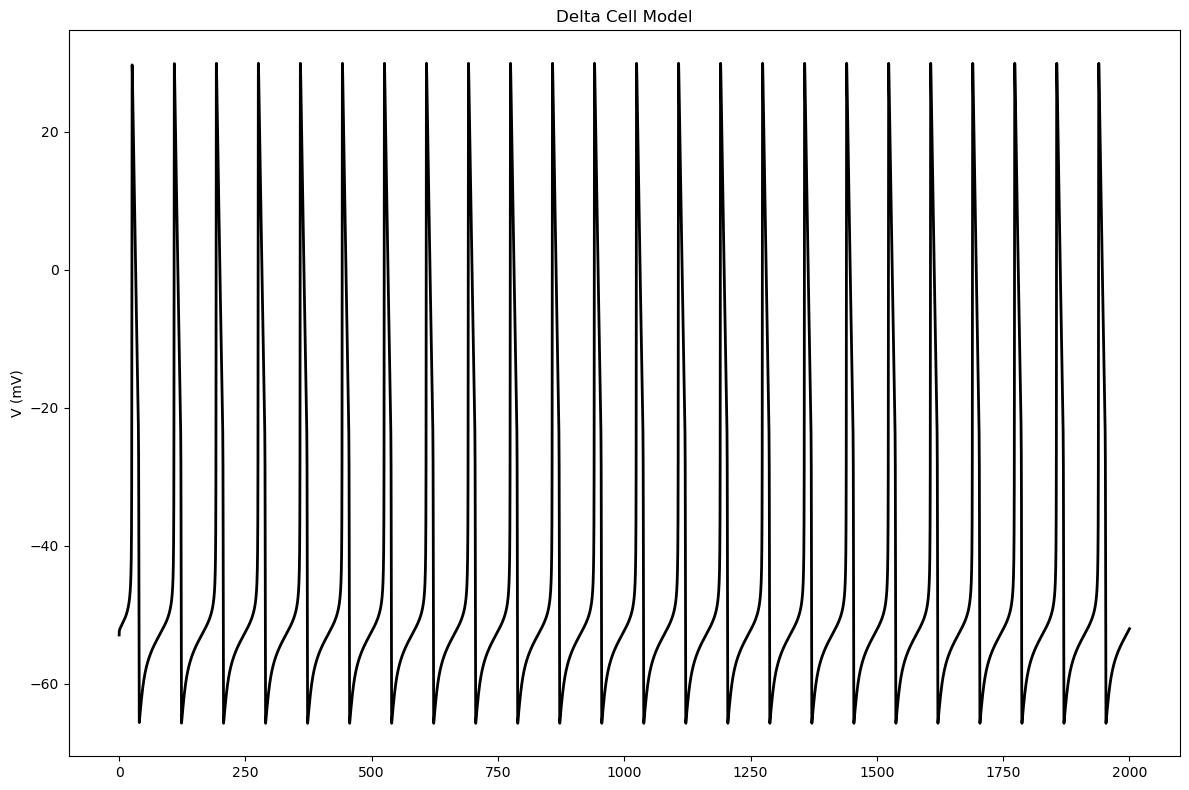

In [5]:
def main():
    # Create a network of 10 beta cells
    network = SingleDeltaCell()


    # Simulate network dynamics
    sol = network.simulate()

    # Plot results
    network.plot_results(sol)


main()

In [6]:
class SingleDeltaCell:
    def __init__(self, **kwargs):
        """
        Initialize a single delta cell model based on Briant et al.

        Parameters:
        -----------
        **kwargs: Parameter overrides for the delta cell model
        """
        # Default parameters
        self.params = {
            "gkatp": 0.01,
            "gna": 11,
            "gka": 1.2,
            "gkdr": 4.5,
            "vna": 60,
            "vk": -75,
            "vca": 65,
            "vl": -40,
            "cm": 4e-3,
            "gcal": 0.65,
            "gcat": 0.05,
            "gcan": 0.3,
            "gl": 0.1,
            "vcalm": -30,
            "scalm": 10,
            "vcalh": -33,
            "scalh": -5,
            "tcalh1": 60,
            "tcalh2": 51,
            "vcatm": -49,
            "scatm": 4,
            "vcath": -52,
            "scath": -5,
            "tcatm1": 15,
            "tcatm2": 0,
            "tcath1": 20,
            "tcath2": 5,
            "vcanm": -5,
            "scanm": 10,
            "vcanh": -33,
            "scanh": -5,
            "tcanh1": 2,
            "tcanh2": 2,
            "vnam": -30,
            "vnah": -52,
            "snam": 4,
            "snah": -8,
            "tnah1": 120,
            "tnah2": 0.5,
            "vkam": -45,
            "skam": 10,
            "vkah": -68,
            "skah": -10,
            "taukam": 0.1,
            "tkah1": 60,
            "tkah2": 5,
            "taukm": 1,
            "vkdrm": -25,
            "skdrm": 23,
            "V2m": -28.8749674,
            "sm": -5.45289598,
            "V2h": -45.388663,
            "sh": 4.99005762,
            "a1taum": 0.0001072,
            "b1taum": 12,
            "c1taum": 40,
            "a2taum": 0.000152,
            "b2taum": -20,
            "c2taum": 22.69,
            "a1tauh": 0.0001636,
            "b1tauh": -15,
            "c1tauh": 8.6856,
            "a2tauh": 0.0001857,
            "b2tauh": 5,
            "c2tauh": 35.35,
        }

        # Update parameters with any provided values
        self.params.update(kwargs)

        # Default initial conditions
        self.init = {
            "v": -52.91,
            "mcal": 0.092,
            "hcal": 0.857,
            "mcat": 0.27,
            "hcat": 0.534,
            "mcan": 0.008,
            "hcan": 0.857,
            "mna": 0.003,
            "hna": 0.339,
            "mka": 0.312,
            "hka": 0.182,
            "mkdr": 0.237,
        }

    def dynamics(self, t, y, v_neighbors=None, g_total=0):
        """
        Calculate the dynamics of the delta cell model

        Parameters:
        -----------
        t : float
            Current time
        y : array-like
            State variables: [v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr]
        v_neighbors : float or None
            Average voltage of neighboring cells
        g_total : float
            Total gap junction conductance to neighbors

        Returns:
        --------
        dydt : array
            Derivatives of state variables
        """
        v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr = y
        p = self.params

        # Steady states and time constants
        mcalinf = 1 / (1 + np.exp(-(v - p["vcalm"]) / p["scalm"]))
        hcalinf = 1 / (1 + np.exp(-(v - p["vcalh"]) / p["scalh"]))
        taucalm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucalh = (p["tcalh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcalh2"]

        mcatinf = 1 / (1 + np.exp(-(v - p["vcatm"]) / p["scatm"]))
        hcatinf = 1 / (1 + np.exp(-(v - p["vcath"]) / p["scath"]))
        taucatm = (p["tcatm1"] / (np.exp(-(v + 50) / 12) + np.exp((v + 50) / 12))) + p[
            "tcatm2"
        ]
        taucath = (p["tcath1"] / (np.exp(-(v + 50) / 15) + np.exp((v + 50) / 15))) + p[
            "tcath2"
        ]

        mcaninf = 1 / (1 + np.exp(-(v - p["vcanm"]) / p["scanm"]))
        hcaninf = 1 / (1 + np.exp(-(v - p["vcanh"]) / p["scanh"]))
        taucanm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucanh = (p["tcanh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcanh2"]

        mnainf = 1 / (1 + np.exp((v - p["V2m"]) / p["sm"]))
        hnainf = 1 / (1 + np.exp((v - p["V2h"]) / p["sh"]))
        taunam = 1e3 * (
            p["a1taum"] * np.exp(-(((v - p["b1taum"]) / p["c1taum"]) ** 2))
            + p["a2taum"] * np.exp(-(((v - p["b2taum"]) / p["c2taum"]) ** 2))
        )
        taunah = 1e3 * (
            p["a1tauh"] * np.exp(-(((v - p["b1tauh"]) / p["c1tauh"]) ** 2))
            + p["a2tauh"] * np.exp(-(((v - p["b2tauh"]) / p["c2tauh"]) ** 2))
        )

        mkainf = 1 / (1 + np.exp(-(v - p["vkam"]) / p["skam"]))
        hkainf = 1 / (1 + np.exp(-(v - p["vkah"]) / p["skah"]))
        taukah = (p["tkah1"] / (np.exp(-(v - 5) / 20) + np.exp((v - 5) / 20))) + p[
            "tkah2"
        ]

        mkdrinf = 1 / (1 + np.exp(-(v - p["vkdrm"]) / p["skdrm"]))
        taukdrm = p["taukm"] * (
            (1.5 / (np.exp(-(v + 10) / 25) + np.exp((v + 10) / 25))) + 15
        )

        # Ionic currents
        Ical = p["gcal"] * mcal**2 * hcal * (v - p["vca"])
        Icat = p["gcat"] * mcat**3 * hcat * (v - p["vca"])
        Ican = p["gcan"] * mcan * hcan * (v - p["vca"])
        Ina = p["gna"] * mna**5 * hna * (v - p["vna"])
        Ika = p["gka"] * mka * hka * (v - p["vk"])
        Ikdr = p["gkdr"] * mkdr**4 * (v - p["vk"])
        Ikatp = p["gkatp"] * (v - p["vk"])
        Il = p["gl"] * (v - p["vl"])

        # Gap junction current
        Igj = g_total * (v_neighbors - v) if v_neighbors is not None else 0

        # Differential equations
        dydt = np.zeros(12)
        dydt[0] = (
            -(Ical + Icat + Ican + Ina + Ikdr + Ikatp + Ika + Il - Igj) / p["cm"]
        )  # dv
        dydt[1] = (mcalinf - mcal) / (1 * taucalm)  # dmcal
        dydt[2] = (hcalinf - hcal) / (1 * taucalh)  # dhcal
        dydt[3] = (mcatinf - mcat) / (1 * taucatm)  # dmcat
        dydt[4] = (hcatinf - hcat) / (1 * taucath)  # dhcat
        dydt[5] = (mcaninf - mcan) / (1 * taucanm)  # dmcan
        dydt[6] = (hcaninf - hcan) / (1 * taucanh)  # dhcan
        dydt[7] = (mnainf - mna) / taunam  # dmna
        dydt[8] = (hnainf - hna) / taunah  # dhna
        dydt[9] = (mkainf - mka) / p["taukam"]  # dmka
        dydt[10] = (hkainf - hka) / taukah  # dhka
        dydt[11] = (mkdrinf - mkdr) / taukdrm  # dmkdr

        return dydt

    def simulate(self, tmax=2000, max_step=5.0):
        """
        Simulate the delta cell model

        Parameters:
        -----------
        tmax : float
            Maximum simulation time in ms
        max_step : float
            Maximum step size for the solver

        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """
        # Initial conditions vector
        y0 = [
            self.init[k]
            for k in [
                "v",
                "mcal",
                "hcal",
                "mcat",
                "hcat",
                "mcan",
                "hcan",
                "mna",
                "hna",
                "mka",
                "hka",
                "mkdr",
            ]
        ]

        tspan = (0, tmax)

        # Solve ODE
        sol = solve_ivp(
            self.dynamics,
            tspan,
            y0,
            method="LSODA",
            max_step=max_step,
            rtol=1e-8,
            atol=1e-8,
        )

        return sol

    def plot_results(self, sol, figure_size=(12, 8)):
        """
        Plot the simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        """
        plt.figure(figsize=figure_size)

        # Plot voltage
        plt.plot(sol.t, sol.y[0], color="black", linewidth=2)
        plt.ylabel("V (mV)")
        plt.title("Delta Cell Model")

        plt.tight_layout()
        plt.show()


class BetaCellNetwork:
    def __init__(
        self, num_cells=3, coupling_strength=0.001, topology="chain", **cell_kwargs
    ):
        """
        Initialize a network of beta cells

        Parameters:
        -----------
        num_cells : int
            Number of cells in the network
        coupling_strength : float
            Strength of gap junction coupling
        topology : str
            Network topology ('chain', 'ring', 'fully_connected')
        **cell_kwargs :
            Parameters to pass to each cell
        """
        self.num_cells = num_cells
        self.coupling_strength = coupling_strength
        self.topology = topology

        # Create cells
        self.cells = [SingleDeltaCell(**cell_kwargs) for _ in range(num_cells)]

        # Create network graph
        self.create_network()

        # Initial conditions with slightly different starting voltages
        # This helps visualize synchronization
        self.init_states()

    def create_network(self):
        """Create the network graph based on specified topology"""
        self.graph = nx.Graph()

        # Add nodes
        for i in range(self.num_cells):
            self.graph.add_node(i)

        # Add edges based on topology
        if self.topology == "chain":
            for i in range(self.num_cells - 1):
                self.graph.add_edge(i, i + 1)

        elif self.topology == "ring":
            for i in range(self.num_cells):
                self.graph.add_edge(i, (i + 1) % self.num_cells)

        elif self.topology == "fully_connected":
            for i in range(self.num_cells):
                for j in range(i + 1, self.num_cells):
                    self.graph.add_edge(i, j)

    def init_states(self):
        """Initialize state variables for all cells with slight variations"""
        self.y0 = np.zeros(12 * self.num_cells)

        for i in range(self.num_cells):
            # Get base initial conditions
            cell_y0 = [
                self.cells[i].init[k]
                for k in [
                    "v",
                    "mcal",
                    "hcal",
                    "mcat",
                    "hcat",
                    "mcan",
                    "hcan",
                    "mna",
                    "hna",
                    "mka",
                    "hka",
                    "mkdr",
                ]
            ]

            # Add small random variation to voltage initial condition
            # This causes cells to start in different phases
            cell_y0[0] += np.random.uniform(-5, 5)

            # Set in overall state vector
            self.y0[i * 12 : (i + 1) * 12] = cell_y0

    def network_dynamics(self, t, y):
        """
        Calculate dynamics for the entire network

        Parameters:
        -----------
        t : float
            Current time
        y : array-like
            State variables for all cells concatenated

        Returns:
        --------
        dydt : array
            Derivatives of all state variables
        """
        dydt = np.zeros_like(y)

        # Process each cell
        for i in range(self.num_cells):
            # Extract state variables for this cell
            cell_y = y[i * 12 : (i + 1) * 12]
            cell_v = cell_y[0]

            # Calculate average voltage of neighbors
            v_neighbors = 0
            num_neighbors = 0

            for neighbor in self.graph.neighbors(i):
                v_neighbors += y[neighbor * 12]  # Voltage is the first state variable
                num_neighbors += 1

            if num_neighbors > 0:
                v_neighbors /= num_neighbors
                g_total = self.coupling_strength * num_neighbors
            else:
                v_neighbors = cell_v  # No neighbors, no coupling
                g_total = 0

            # Get dynamics for this cell
            cell_dydt = self.cells[i].dynamics(t, cell_y, v_neighbors, g_total)

            # Update overall dydt
            dydt[i * 12 : (i + 1) * 12] = cell_dydt

        return dydt

    def simulate(self, tmax=2000, max_step=5.0):
        """
        Simulate the network dynamics

        Parameters:
        -----------
        tmax : float
            Maximum simulation time
        max_step : float
            Maximum step size for the solver

        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """
        tspan = (0, tmax)

        # Solve the system
        sol = solve_ivp(
            self.network_dynamics,
            tspan,
            self.y0,
            method="LSODA",
            max_step=max_step,
            rtol=1e-8,
            atol=1e-8,
        )

        return sol

    def plot_results(self, sol, voltage_only=True, figure_size=(12, 8)):
        """
        Plot the simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        voltage_only : bool
            If True, only plot voltage traces
        """
        plt.figure(figsize=figure_size)

        # Extract voltages for each cell
        for i in range(self.num_cells):
            v = sol.y[i * 12]
            plt.plot(sol.t, v, label=f"Cell {i+1}")

        plt.xlabel("Time (ms)")
        plt.ylabel("Voltage (mV)")
        plt.title(f"Beta Cell Network (Coupling: {self.coupling_strength})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_phase_portrait(
        self, sol, cell_indices=(0, 1), tskip=1000, figure_size=(10, 10)
    ):
        """
        Plot phase portrait for two cells to visualize synchronization

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        cell_indices : tuple
            Indices of the two cells to plot
        tskip : float
            Skip initial transient time
        """
        # Find time index to start from (skip initial transient)
        tstart_idx = np.argmax(sol.t > tskip) if tskip > 0 else 0

        # Get voltages for the two cells
        v1 = sol.y[cell_indices[0] * 12][tstart_idx:]
        v2 = sol.y[cell_indices[1] * 12][tstart_idx:]

        plt.figure(figsize=figure_size)
        plt.plot(v1, v2)
        plt.xlabel(f"Cell {cell_indices[0]+1} Voltage (mV)")
        plt.ylabel(f"Cell {cell_indices[1]+1} Voltage (mV)")
        plt.title(f"Phase Portrait (Coupling: {self.coupling_strength})")

        # Plot diagonal line for reference (perfect synchronization)
        vmin = min(np.min(v1), np.min(v2))
        vmax = max(np.max(v1), np.max(v2))
        plt.plot([vmin, vmax], [vmin, vmax], "k--", alpha=0.5)

        plt.grid(True)
        plt.tight_layout()
        plt.show()


def analyze_synchronization(
    coupling_values, num_cells=3, topology="chain", tmax=5000, tskip=3000
):
    """
    Analyze synchronization across different coupling strengths

    Parameters:
    -----------
    coupling_values : list
        List of coupling strengths to test
    num_cells : int
        Number of cells in network
    topology : str
        Network topology
    tmax : float
        Simulation time
    tskip : float
        Time to skip initial transients

    Returns:
    --------
    sync_measures : dict
        Dictionary of synchronization measures
    """
    sync_measures = {"coupling": coupling_values, "correlation": []}

    for g in coupling_values:
        print(f"Simulating with coupling strength {g:.6f}")
        network = BetaCellNetwork(
            num_cells=num_cells, coupling_strength=g, topology=topology
        )
        sol = network.simulate(tmax=tmax)

        # Calculate correlation between cell voltages after transient
        tstart_idx = np.argmax(sol.t > tskip) if tskip > 0 else 0

        # Get all cell voltages
        voltages = np.zeros((num_cells, len(sol.t[tstart_idx:])))
        for i in range(num_cells):
            voltages[i, :] = sol.y[i * 12][tstart_idx:]

        # Calculate average correlation
        corr_sum = 0
        count = 0
        for i in range(num_cells):
            for j in range(i + 1, num_cells):
                corr = np.corrcoef(voltages[i, :], voltages[j, :])[0, 1]
                corr_sum += corr
                count += 1

        avg_corr = corr_sum / count if count > 0 else 0
        sync_measures["correlation"].append(avg_corr)

    return sync_measures


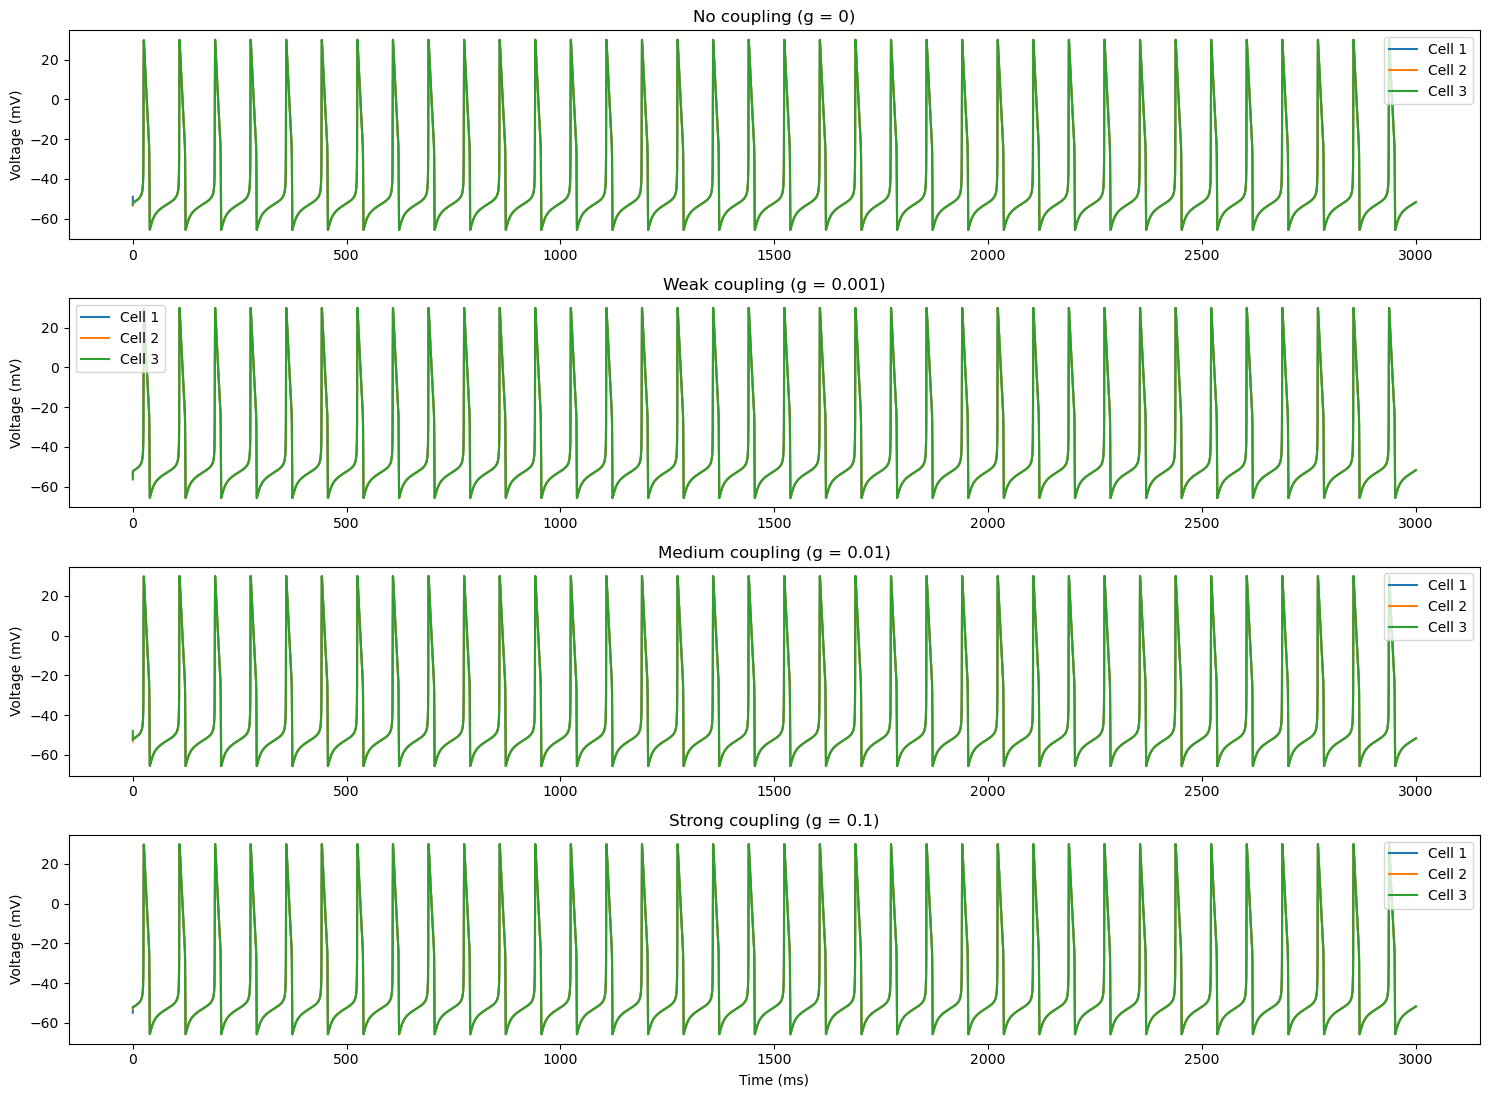

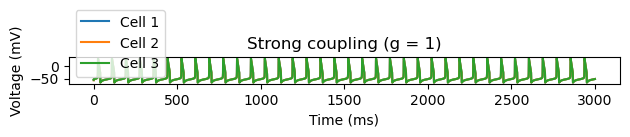

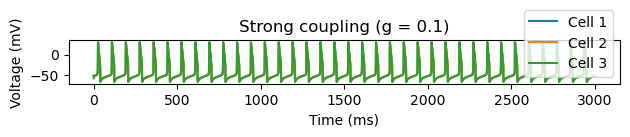

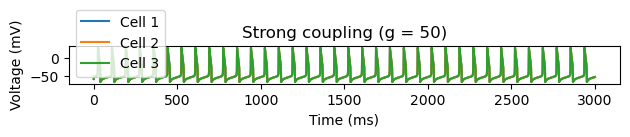

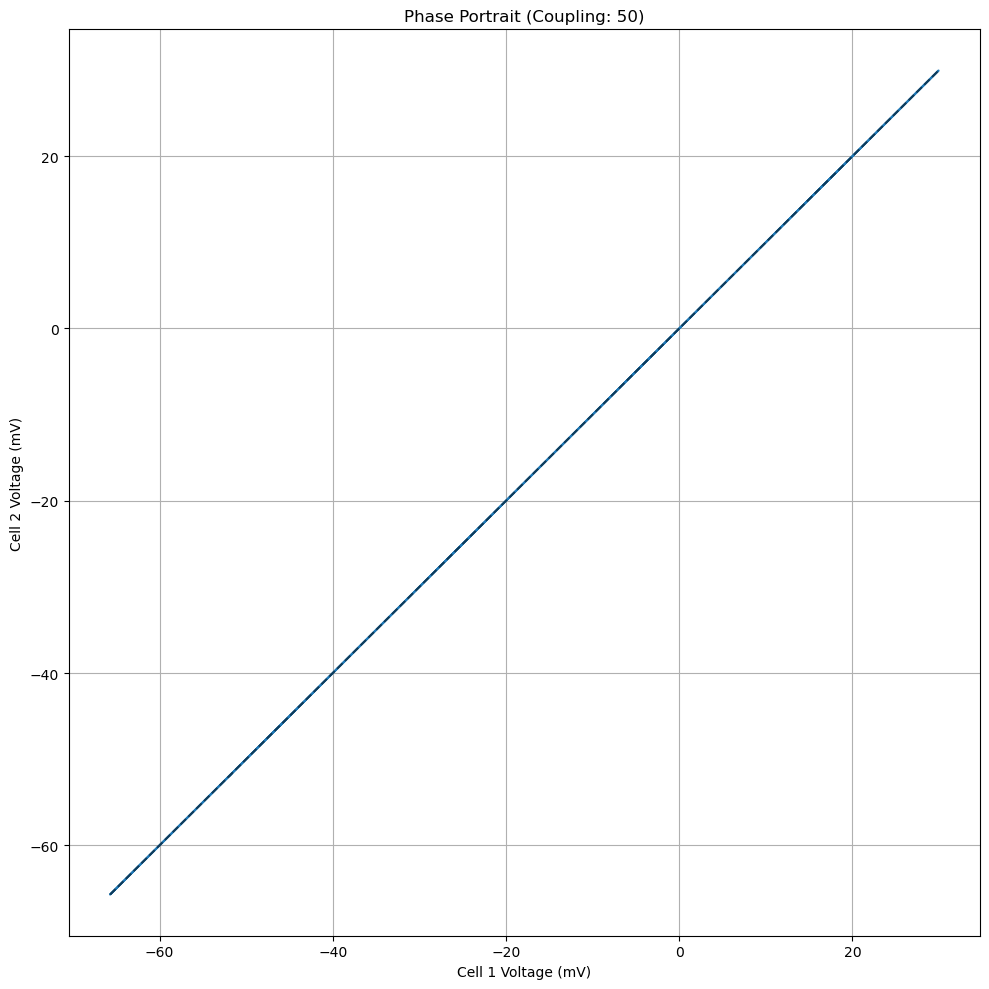

Simulating with coupling strength 0.000000
Simulating with coupling strength 0.000010
Simulating with coupling strength 0.000100
Simulating with coupling strength 0.001000
Simulating with coupling strength 0.010000
Simulating with coupling strength 0.100000


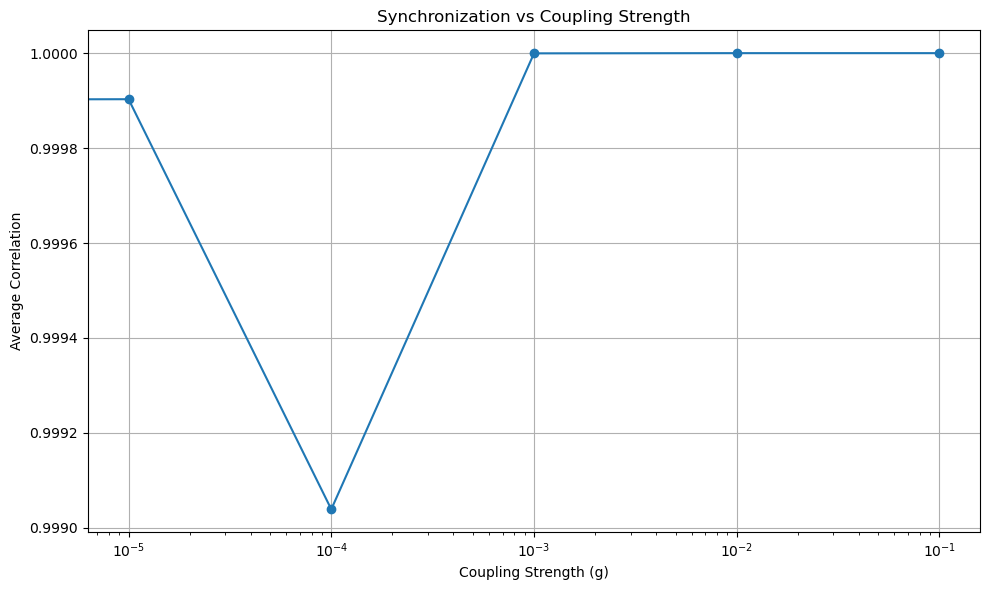

In [7]:
def main():
    # Define a range of coupling strengths to test
    coupling_values = [0, 0.0001, 0.001, 0.01, 0.1]

    # Create and simulate a small beta cell network with four different coupling strengths
    plt.figure(figsize=(15, 16))  # Made taller to fit 4 subplots

    # Example 1: Chain of 3 cells with no coupling
    network1 = BetaCellNetwork(num_cells=3, coupling_strength=0, topology="chain")
    sol1 = network1.simulate(tmax=3000)

    plt.subplot(6, 1, 1)
    for i in range(3):  # Changed from range(4) to range(3)
        plt.plot(sol1.t, sol1.y[i * 12], label=f"Cell {i+1}")
    plt.title("No coupling (g = 0)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

    # Example 2: Chain of 3 cells with weak coupling
    network2 = BetaCellNetwork(num_cells=3, coupling_strength=0.001, topology="chain")
    sol2 = network2.simulate(tmax=3000)

    plt.subplot(6, 1, 2)
    for i in range(3):
        plt.plot(sol2.t, sol2.y[i * 12], label=f"Cell {i+1}")
    plt.title("Weak coupling (g = 0.001)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

    # Example 3: Chain of 3 cells with medium coupling
    network3 = BetaCellNetwork(num_cells=3, coupling_strength=0.01, topology="chain")
    sol3 = network3.simulate(tmax=3000)

    plt.subplot(6, 1, 3)
    for i in range(3):
        plt.plot(sol3.t, sol3.y[i * 12], label=f"Cell {i+1}")
    plt.title("Medium coupling (g = 0.01)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

    # Example 4: Chain of 3 cells with strong coupling
    network4 = BetaCellNetwork(num_cells=3, coupling_strength=0.1, topology="chain")
    sol4 = network4.simulate(tmax=3000)

    plt.subplot(6, 1, 4)
    for i in range(3):
        plt.plot(sol4.t, sol4.y[i * 12], label=f"Cell {i+1}")
    plt.title("Strong coupling (g = 0.1)")  # Fixed the title
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Example 5: Chain of 3 cells with strong coupling
    network4 = BetaCellNetwork(num_cells=3, coupling_strength=1, topology="chain")
    sol4 = network4.simulate(tmax=3000)

    plt.subplot(6, 1, 5)
    for i in range(3):
        plt.plot(sol4.t, sol4.y[i * 12], label=f"Cell {i+1}")
    plt.title("Strong coupling (g = 1)")  # Fixed the title
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Example 4: Chain of 3 cells with strong coupling
    network4 = BetaCellNetwork(num_cells=3, coupling_strength=0.1, topology="chain")
    sol4 = network4.simulate(tmax=3000)

    plt.subplot(5, 1, 4)
    for i in range(3):
        plt.plot(sol4.t, sol4.y[i * 12], label=f"Cell {i+1}")
    plt.title("Strong coupling (g = 0.1)")  # Fixed the title
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Example 6: Chain of 3 cells with strong coupling
    network4 = BetaCellNetwork(num_cells=3, coupling_strength=50, topology="chain")
    sol4 = network4.simulate(tmax=3000)

    plt.subplot(6, 1, 6)
    for i in range(3):
        plt.plot(sol4.t, sol4.y[i * 12], label=f"Cell {i+1}")
    plt.title("Strong coupling (g = 50)")  # Fixed the title
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot phase portraits to visualize synchronization
    # Use network4 (strong coupling) for phase portrait
    network4.plot_phase_portrait(sol4, cell_indices=(0, 1), tskip=2000)

    # Analyze synchronization across multiple coupling strengths
    sync_results = analyze_synchronization(
        coupling_values=[0, 0.00001, 0.0001, 0.001, 0.01, 0.1],
        num_cells=3,
        topology="chain",
    )

    plt.figure(figsize=(10, 6))
    plt.plot(sync_results["coupling"], sync_results["correlation"], "o-")
    plt.xscale("log")
    plt.xlabel("Coupling Strength (g)")
    plt.ylabel("Average Correlation")
    plt.title("Synchronization vs Coupling Strength")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()